# UIDEP (Universal Instrument Data Exchange Protocol)
is a protocol developed by Aerosol d.o.o. for standardized data exchange between instruments and data acquisition systems. It allows for real-time data retrieval, control and monitoring of compatible instruments.

UIDEP works with **AE36s**, **AE36**, **TCA08** and **TCA09** instruments, while **AE33 is not supported**.

If start and end are not given, protocol will return the most recent data. If only start is given, the instrument will return data from start to the current time. Only End without start is not allowed option.

You can limit the number of returned components by setting the `component` parameter - you can check component IDs if you prepare an url without components (first example).

**Important Note:** UIDEP is designed for real-time data access and may not be suitable for retrieving large historical datasets. For historical data retrieval, consider using the smaller chunks of daily/monthly datasets and not the whole history at once.

**License:** Aerosol Magee Scientific Software License (See LICENSE file for full terms).

In [33]:
from datetime import date, timedelta, datetime

import pandas as pd

from aerosol_magee_pytools.data_access.uidep import uidep_get_data, uidep_url

In [34]:
# your instrument IP address - change it to the actual IP address of your instrument
instrument_ip = '10.10.10.80' # Skylab AE36s
# instrument_ip = '10.10.10.133' # Skylab TCA08
# instrument_ip = '10.10.10.61' # Skylab TCA09

In [35]:
# limit start and end to a short period to avoid large data retrieval

# star and end could be datetime objects ...
start = datetime.now() - timedelta(hours=12)
end = datetime.now() - timedelta(hours=1)

# # ... or strings in ISO format
# start = date.today().isoformat()
# end = (date.today() + timedelta(hours=1)).isoformat()
#
# start = '2026-06-10 14:30'
# end = '2026-06-10 14:40'

#################################################################
# components have different IDs for different instruments, check your instrument documentation for details
# for example, for AE36s & AE36, you can choose following subset:
components_subset = [3,  # EndTimeUTC
                     5, # EndTimeLocal
                     88]  # BC880
instrument_typ = 'AE36s'  # used only in plot example at the end

# # for TCA08, logical choose would be:
# components_subset = [3, # EndTimeUTC
#                      5, # EndTimeLocal
#                      1, # SampleID
#                      8, # TCconc
#                      16] # Chamber
# instrument_typ = 'TCA08' # used only in plot example at the end
#
# # for TCA09, logical choose would be:
# components_subset = [6, # SampleEndTimeUTC
#                      1, # SampleID
#                      16, # G1_Status
#                      29, # TCconc_volume
#                      23] # Chamber
# instrument_typ = 'TCA09' # used only in plot example at the end

In [36]:
# get UIDEP urls - different options
# copy url to your browser and you will get data

print(uidep_url(ip=instrument_ip))  # complex value type by default
print(uidep_url(ip=instrument_ip, values_typ='simple'))
# print(uidep_url(ip=instrument_ip, start='2026-06-10 14:30'))
# print(uidep_url(ip=instrument_ip, start='2026-06-10 14:30', end='2026-06-10 14:40'))
# print(uidep_url(ip=instrument_ip, start='2026-06-10 14:30', end='2026-06-10 14:40', components=3))
# print(uidep_url(ip=instrument_ip, start='2026-06-10 14:30', end='2026-06-10 14:40', components=[3, 91, 92]))
print(uidep_url(ip=instrument_ip, start=start))
print(uidep_url(ip=instrument_ip, start=start, end=end))
print(uidep_url(ip=instrument_ip, start=start, end=end, components=3))
print(uidep_url(ip=instrument_ip, start=start, end=end, components=[3, 4, 5]))
print(uidep_url(ip=instrument_ip, start=start, end=end, components=components_subset))
print(uidep_url(ip=instrument_ip, components=components_subset))

http://10.10.10.80:8080/values/complex/
http://10.10.10.80:8080/values/simple/
http://10.10.10.80:8080/values/complex/?start=2026-06-10-04-14-18
http://10.10.10.80:8080/values/complex/?start=2026-06-10-04-14-18&end=2026-06-10-15-14-18
http://10.10.10.80:8080/values/complex/?start=2026-06-10-04-14-18&end=2026-06-10-15-14-18&component=3
http://10.10.10.80:8080/values/complex/?start=2026-06-10-04-14-18&end=2026-06-10-15-14-18&component=3&component=4&component=5
http://10.10.10.80:8080/values/complex/?start=2026-06-10-04-14-18&end=2026-06-10-15-14-18&component=3&component=5&component=88
http://10.10.10.80:8080/values/complex/?component=3&component=5&component=88


**Parse received data to DataFrame** - works only with a complex value type.

If you want to use a simple value type, you will need to parse the data yourself – it is a list of values without column names.

**Note:** Last/current data entry conversion to DataFrame is not supported.

In [37]:
# example: all columns for limited times
df = uidep_get_data(ip=instrument_ip, start=start, end=end)
print(df.head())

        ID        TimestampUTC         StartTimeUTC           EndTimeUTC  \
0  4991004  639166545000000000  2026-06-10 02:14:00  2026-06-10 02:15:00   
1  4991005  639166545600000000  2026-06-10 02:15:00  2026-06-10 02:16:00   
2  4991006  639166546200000000  2026-06-10 02:16:00  2026-06-10 02:17:00   
3  4991007  639166546800000000  2026-06-10 02:17:00  2026-06-10 02:18:00   
4  4991008  639166547400000000  2026-06-10 02:18:00  2026-06-10 02:19:00   

        StartTimeLocal         EndTimeLocal  SetupID       SetupTimestamp  \
0  2026-06-10 04:14:00  2026-06-10 04:15:00       56  2026-06-05 14:23:52   
1  2026-06-10 04:15:00  2026-06-10 04:16:00       56  2026-06-05 14:23:52   
2  2026-06-10 04:16:00  2026-06-10 04:17:00       56  2026-06-05 14:23:52   
3  2026-06-10 04:17:00  2026-06-10 04:18:00       56  2026-06-05 14:23:52   
4  2026-06-10 04:18:00  2026-06-10 04:19:00       56  2026-06-05 14:23:52   

   G0_Status  G1_Status  G2_Status  G3_Status  G4_Status  G5_Status  \
0        

In [38]:
# example: limited number of components (column IDs)
df = uidep_get_data(ip=instrument_ip, start=start, end=end, components=3)
print(df)

              EndTimeUTC
0    2026-06-10 02:15:00
1    2026-06-10 02:16:00
2    2026-06-10 02:17:00
3    2026-06-10 02:18:00
4    2026-06-10 02:19:00
..                   ...
655  2026-06-10 13:10:00
656  2026-06-10 13:11:00
657  2026-06-10 13:12:00
658  2026-06-10 13:13:00
659  2026-06-10 13:14:00

[660 rows x 1 columns]


In [39]:
# example: limited number of components (column IDs)
df = uidep_get_data(ip=instrument_ip, start=start, end=end, components=components_subset)
print(df)

              EndTimeUTC         EndTimeLocal  BC880
0    2026-06-10 02:15:00  2026-06-10 04:15:00    117
1    2026-06-10 02:16:00  2026-06-10 04:16:00    136
2    2026-06-10 02:17:00  2026-06-10 04:17:00    153
3    2026-06-10 02:18:00  2026-06-10 04:18:00    139
4    2026-06-10 02:19:00  2026-06-10 04:19:00    138
..                   ...                  ...    ...
655  2026-06-10 13:10:00  2026-06-10 15:10:00    385
656  2026-06-10 13:11:00  2026-06-10 15:11:00    504
657  2026-06-10 13:12:00  2026-06-10 15:12:00    460
658  2026-06-10 13:13:00  2026-06-10 15:13:00    269
659  2026-06-10 13:14:00  2026-06-10 15:14:00    349

[660 rows x 3 columns]


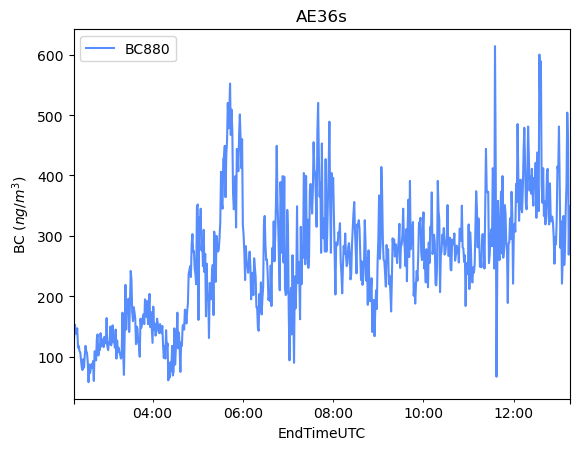

In [40]:
# plot data
if instrument_typ in ['AE36s', 'AE36']:
    df['EndTimeUTC'] = pd.to_datetime(df['EndTimeUTC'], errors='coerce')
    df.plot(x='EndTimeUTC', y='BC880', title=f'{instrument_typ}', ylabel='BC ($ng/m^3$)')

elif instrument_typ == 'TCA08':
    df['EndTimeUTC'] = pd.to_datetime(df['EndTimeUTC'], errors='coerce')
    df.plot(x='EndTimeUTC', y='TCconc', title=f'{instrument_typ}', ylabel='TC ($ng/m^3$)')

elif instrument_typ == 'TCA09':
    df = df[df['SampleEndTimeUTC'] != 0]
    df['SampleEndTimeUTC'] = pd.to_datetime(df['SampleEndTimeUTC'], errors='coerce')
    df.plot(x='SampleEndTimeUTC', y='TCconc_volume', title=f'{instrument_typ}', ylabel='TC ($ng/m^3$)')